In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

from Scripts_Imane import features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralBiclustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import consensus_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
# ======== Creating csv from txt file GO annotations ========
txt_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.txt"
csv_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv"
df = pd.read_csv(txt_file, sep=None, engine="python", dtype=str)
if df.shape[1] == 1:
    df = pd.read_csv(txt_file, sep=",", header=None, dtype=str, engine="python")
    df.columns = [
        "Gene Name","Transcript Name","KEGG ID","PFAM ID","Pathway ID","Pathway Description",
        "GO ID","GO Description","Panther ID","Panther Description","Description"
    ]
df.to_csv(csv_file, index=False)
print(df.shape)

In [15]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
data = features.add_GO_old(data)#, "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/GOmart_export.csv")
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv', index=False)

In [16]:
### Biclustering

def to_go_list(x):
    if isinstance(x, list):
        return [g for g in x if pd.notna(g)]
    if isinstance(x, str):
        return [g for g in x.split() if g]  
    return []
data['GO'] = data['GO'].apply(to_go_list)

data['n_GO_per_gene'] = data['GO'].apply(len)
n_go_per_gene = data[['mutated_genes', 'n_GO_per_gene']]

all_go = set()
_ = data['GO'].apply(all_go.update)
n_go_total = len(all_go)

print(f"# gènes = {data['mutated_genes'].nunique()}")
print(f"# GO terms distincts = {n_go_total}")

exploded = data[['mutated_genes', 'GO']].explode('GO').dropna()
X = pd.crosstab(exploded['mutated_genes'], exploded['GO']).astype(np.int8)

MIN_GENES_PER_GO = 0
keep_go = (X.sum(axis=0) >= MIN_GENES_PER_GO)  #axis=0 for columns
X = X.loc[:, keep_go]

print(f"# GO terms après filtre (≥{MIN_GENES_PER_GO} gènes) = {X.shape[1]}")

gene_to_go = data[['mutated_genes', 'GO']].drop_duplicates('mutated_genes')
def to_go_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return x.split()
    return []
gene_to_go['GO'] = gene_to_go['GO'].apply(to_go_list)
gene_to_go['n_GO'] = gene_to_go['GO'].apply(len)
go_dist = gene_to_go['n_GO'].value_counts().sort_index()
print(f"# gènes uniques = {gene_to_go.shape[0]}")
print("Distribution (#GO terms → #genes):")
print(go_dist)
go_dist_df = go_dist.reset_index()
go_dist_df.columns = ['n_GO_terms', 'n_genes']
print(go_dist_df.head(20))

N_GENE_CLUSTERS = 8
N_GO_CLUSTERS = 8

model = SpectralBiclustering(
    n_clusters=(N_GENE_CLUSTERS, N_GO_CLUSTERS),
    random_state=0
)
model.fit(X)

gene_labels = pd.Series(model.row_labels_, index=X.index, name='gene_cluster')
go_labels   = pd.Series(model.column_labels_, index=X.columns, name='go_cluster')

row_order = np.argsort(model.row_labels_)
col_order = np.argsort(model.column_labels_)
X_ordered = X.iloc[row_order, col_order]

gene_cluster_table = gene_labels.to_frame().reset_index(names='mutated_genes')
go_cluster_table   = go_labels.to_frame().reset_index(names='GO')

# plt.figure(figsize=(8, 6))
# plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
# plt.title('Biclustering (X réordonnée)')
# plt.xlabel('GO (réordonné)')
# plt.ylabel('Gènes (réordonné)')
# plt.colorbar(label='Présence GO')
# plt.tight_layout()
# plt.show()

print("\n--- Aperçu gènes par cluster ---")
print(gene_cluster_table['gene_cluster'].value_counts().sort_index())
print("\n--- Aperçu GO par cluster ---")
print(go_cluster_table['go_cluster'].value_counts().sort_index())

def get_block_members(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

# rows, cols = get_block_members(0, 0)
# print("Gènes du bloc (0,0):", rows[:10])
# print("GO du bloc (0,0):", cols[:10])
k = N_GENE_CLUSTERS
rows = gene_labels[gene_labels == k].index  
cols = go_labels[go_labels == k].index  
print(f"Bicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
print("Genes:", rows[:10].tolist())   # print first 10
print("GO terms:", cols[:10].tolist())
for k in range(model.n_clusters[0]):
    rows = gene_labels[gene_labels == k].index
    cols = go_labels[go_labels == k].index
    print(f"\nBicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
    print("Genes (first 100):", rows[:100].tolist())
    print("GO terms (first 10):", cols[:10].tolist())

# gènes = 589
# GO terms distincts = 275
# GO terms après filtre (≥0 gènes) = 266
# gènes uniques = 589
Distribution (#GO terms → #genes):
n_GO
0     245
1      84
2      60
3      74
4      68
5      35
6      14
7       5
8       3
10      1
Name: count, dtype: int64
   n_GO_terms  n_genes
0           0      245
1           1       84
2           2       60
3           3       74
4           4       68
5           5       35
6           6       14
7           7        5
8           8        3
9          10        1

--- Aperçu gènes par cluster ---
gene_cluster
0     44
1     26
2     20
3     21
4     15
5      2
6    215
7      1
Name: count, dtype: int64

--- Aperçu GO par cluster ---
go_cluster
0    236
1      3
2      3
3      1
4      6
5      8
6      8
7      1
Name: count, dtype: int64
Bicluster 8: 0 genes, 0 GO terms
Genes: []
GO terms: []

Bicluster 0: 44 genes, 236 GO terms
Genes (first 100): ['Cre01.g012650', 'Cre01.g012850', 'Cre01.g017200', 'Cre01.g019550', 'Cre01.g023

In [ ]:

# fit two models with different cluster numbers
model1 = SpectralBiclustering(n_clusters=(5,5), random_state=0).fit(X)
model2 = SpectralBiclustering(n_clusters=(10,10), random_state=0).fit(X)

score = consensus_score(model1.biclusters_, model2.biclusters_)
print("Consensus score:", score)


In [21]:
# Stats of how many features
df = data
df_gene = df.groupby('mutated_genes', as_index=False).agg({
    'GO': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Pathway Description': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Panther ID': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    #'KEGG ID' : lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], [])
})

def has_nonempty(x):
    return isinstance(x, list) and len([v for v in x if str(v).strip() != ""]) > 0

df_gene['has_GO']      = df_gene['GO'].apply(has_nonempty)
df_gene['has_pathway'] = df_gene['Pathway Description'].apply(has_nonempty)
df_gene['has_panther'] = df_gene['Panther ID'].apply(has_nonempty)
#df_gene['has_kegg'] = df_gene['KEGG ID'].apply(has_nonempty)

total_genes  = df_gene.shape[0]
with_GO      = df_gene['has_GO'].sum()
with_pathway = df_gene['has_pathway'].sum()
with_panther = df_gene['has_panther'].sum()
#with_kegg = df_gene['has_kegg'].sum()
with_any     = ((df_gene['has_GO']) | (df_gene['has_pathway']) | (df_gene['has_panther']) ).sum()

print(f"Total unique genes: {total_genes}")
print(f"Genes with GO: {with_GO}")
print(f"Genes with Pathway Description: {with_pathway}")
print(f"Genes with Panther ID: {with_panther}")
#print(f"Genes with KEGG: {with_kegg}")
print(f"Genes with at least one (GO or Pathway or Panther): {with_any}")

KeyError: "Column(s) ['Panther ID', 'Pathway Description'] do not exist"

In [ ]:
### predictive power of GO terms
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

data = data[~(data['light_regime']=='20h_ML')]
data = data[~(data['mutated_genes']=='WT')]
def make_X_from_GO(df, gene_col='mutated_genes', go_col='GO', min_genes_per_go=3):
    g = df[[gene_col, go_col]].dropna(subset=[gene_col]).copy()
    import ast, re

    def to_list(x):
        if isinstance(x, list): vals = x
        elif pd.isna(x): return []
        else:
            s = str(x).strip()
            try:
                v = ast.literal_eval(s)
                vals = list(v) if isinstance(v, (list, tuple)) else [s]
            except Exception:
                s = s.strip('[]()').replace('&', ',').replace('|', ',')
                vals = re.split(r'[,\s;]+', s)
        out = []
        for t in vals:
            t = str(t).strip().strip("'\"")
            if not t: continue
            t = t.replace('Go:', 'GO:').replace('GO: ', 'GO:')
            m = re.match(r'^GO:\s*(\d+)$', t)
            if m:
                t = f"GO:{int(m.group(1)):07d}"
                out.append(t)
        return list(dict.fromkeys(out))  # dedup, order-preserving
    g[go_col] = g[go_col].apply(to_list)
    expl = g.explode(go_col).dropna(subset=[go_col])
    X = pd.crosstab(expl[gene_col], expl[go_col]).astype(np.uint8)
    if min_genes_per_go and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]
    return X

X = make_X_from_GO(data, min_genes_per_go=3)
print(X.shape)

Y = data.pivot_table(index='mutated_genes', columns='light_regime',
                   values='y2_slope', aggfunc='mean')
print(Y.shape)

Y = Y.fillna(0)
Y = Y.replace([np.inf, -np.inf], 0)

genes = X.index.intersection(Y.index)
X = X.loc[genes]
Y = Y.loc[genes]
X = X.loc[:, X.sum(axis=0) > 0]


scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y.values)

n_pcs = 7  # number of PCs you want
pca = PCA(n_components=n_pcs)
PC_scores = pca.fit_transform(Y_scaled)

PC_df = pd.DataFrame(PC_scores,
                     index=Y.index,
                     columns=[f"PC{i+1}" for i in range(n_pcs)])
PC_mat = PC_df.loc[X.index].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Fonction pour calculer la RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Création d'un scorer basé sur la RMSE
rmse_scorer = make_scorer(rmse, greater_is_better=False)
results = {}
for pc in range(7):
    y = PC_mat[:, pc]
    model = LassoCV(alphas=np.logspace(-2, 2, 60),max_iter=50000, tol=1e-3, selection='cyclic')
    y_pred = cross_val_predict(model, X_scaled, y, cv=5)
    
    # Metrics
    Rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    norm_rmse = Rmse / np.std(y)  # relative error

    results[f"PC{pc+1}"] = {
        "RMSE": Rmse,
        "Normalized_RMSE": norm_rmse,
        "R2": r2
    }

print(results)

(344, 275)
(588, 7)
{'PC1': {'RMSE': 2.1674508363893694, 'Normalized_RMSE': 1.0067576346673015, 'R2': -0.013560934960899829}, 'PC2': {'RMSE': 0.9392277482067349, 'Normalized_RMSE': 1.0154490736312756, 'R2': -0.0311368211386156}, 'PC3': {'RMSE': 0.7308104241432322, 'Normalized_RMSE': 1.0013475517035362, 'R2': -0.0026969193026662452}, 'PC4': {'RMSE': 0.5937577815848233, 'Normalized_RMSE': 1.0036209875733682, 'R2': -0.007255086697742774}, 'PC5': {'RMSE': 0.5136319571936999, 'Normalized_RMSE': 1.0059341916464768, 'R2': -0.01190359792345097}, 'PC6': {'RMSE': 0.460346814537359, 'Normalized_RMSE': 1.0053822840987408, 'R2': -0.010793537179601076}, 'PC7': {'RMSE': 0.39756030898074474, 'Normalized_RMSE': 1.005037225742437, 'R2': -0.010099825128054185}}


(585, 7)
(344, 275)
Explained variance ratio (par PC): [0.662, 0.115, 0.083, 0.051, 0.035, 0.029, 0.025]


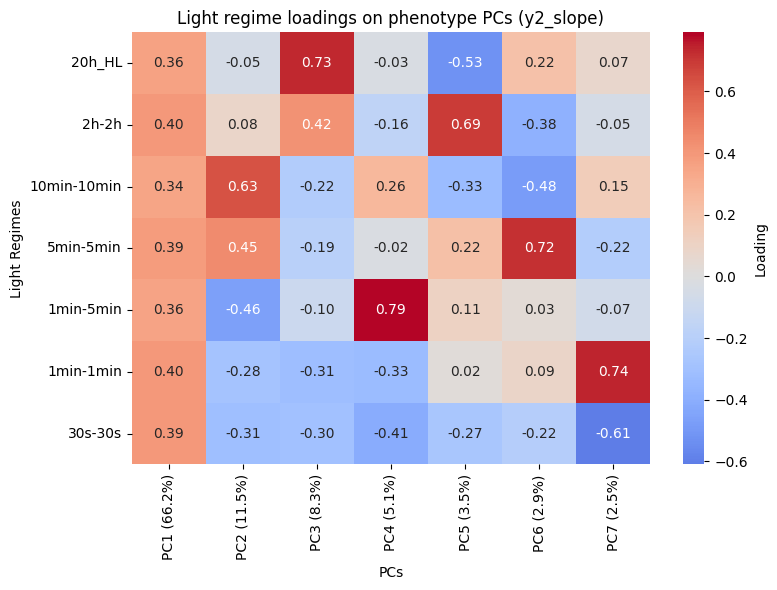

    PC  variance_pct  cum_pct
0  PC1         66.16    66.16
1  PC2         11.49    77.65
2  PC3          8.27    85.93
3  PC4          5.05    90.98
4  PC5          3.55    94.53
5  PC6          2.93    97.45
6  PC7          2.55   100.00

 R² CV par PC:
PC1: -0.021
PC2: -0.007
PC3: -0.007
PC4: -0.028
PC5: -0.010
PC6: -0.034
PC7: -0.006

 RMSE CV par PC:
PC1: 2.139
PC2: 0.887
PC3: 0.751
PC4: 0.587
PC5: 0.498
PC6: 0.453
PC7: 0.419

R² CV moyen (toutes PCs): -0.016
RMSE CV moyen (toutes PCs): 0.819


In [35]:
## pcs projection using go
### predictive power of GO terms
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import ast, re

df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv')
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]
data=df
#data=df_out
def to_list(x):
    if isinstance(x, list): vals = x
    elif pd.isna(x): return []
    else:
        s = str(x).strip()
        try:
            v = ast.literal_eval(s)
            vals = list(v) if isinstance(v, (list, tuple)) else [s]
        except Exception:
            s = s.strip('[]()').replace('&', ',').replace('|', ',')
            vals = re.split(r'[,\s;]+', s)
    out = []
    for t in vals:
        t= str(t).strip().strip("'\"")
        if not t: continue
        t = t.replace('Go:', 'GO:').replace('GO: ', 'GO:')
        m = re.match(r'^GO:\s*(\d+)$', t)
        if m:
            t = f"GO:{int(m.group(1)):07d}"
            out.append(t)
    return list(dict.fromkeys(out))

def make_Y(df, gene_col='mutant_ID', light_col='light_regime', slope_col='y2_slope'):
    g = (df[[gene_col, light_col, slope_col]]
         .dropna(subset=[gene_col, light_col, slope_col]))
    Y = (g.groupby([gene_col, light_col])[slope_col]
           .mean().unstack(light_col))
    Y = Y.dropna(axis=0, how='any')  # gènes avec mesures complètes
    return Y

def make_X_from_GO(df, gene_col='mutated_genes', go_col='GO', min_genes_per_go=3):
    g = df[[gene_col, go_col]].dropna(subset=[gene_col]).copy()
    g[go_col] = g[go_col].apply(to_list)
    expl = g.explode(go_col).dropna(subset=[go_col])
    X = pd.crosstab(expl[gene_col], expl[go_col]).astype(np.uint8)
    if min_genes_per_go and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]
    return X

# ---------------------------------------
# 1) Construire Y (moyenne des slopes)
#    ATTENTION: adapte les noms de colonnes si besoin
# ---------------------------------------
Y = make_Y(data, gene_col='mutated_genes', light_col='light_regime', slope_col='y2_slope')
print(Y.shape)
# ---------------------------------------
# 2) Construire X (gène × GO binaire)
# ---------------------------------------
X = make_X_from_GO(data, gene_col='mutated_genes', go_col='GO', min_genes_per_go=3)
print(X.shape)

# ---------------------------------------
# 3) Aligner X et Y (gènes communs) + clean
# ---------------------------------------
genes = X.index.intersection(Y.index)
X = X.loc[genes]
Y = Y.loc[genes]
X = X.loc[:, X.sum(axis=0) > 0]  # retire features vides

# ---------------------------------------
# 4) PCA sur Y (standardisation conseillée)
# ---------------------------------------
Y = Y.replace([np.inf, -np.inf], 0)

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y.values)

n_pcs = min(8, Y.shape[1])  # ex: 5 PC ou max possible
pca = PCA(n_components=n_pcs, random_state=0)
PC_scores = pca.fit_transform(Y_scaled)
PC_df = pd.DataFrame(PC_scores, index=Y.index,
                     columns=[f'PC{i+1}' for i in range(n_pcs)])

print("Explained variance ratio (par PC):",
      [round(v, 3) for v in pca.explained_variance_ratio_])


pca.fit(Y_scaled)
explained_var = pca.explained_variance_ratio_ * 100
loadings = pd.DataFrame(
    pca.components_.T,   # transpose pour avoir regimes en lignes
    index=Y.columns,     # light regimes
    columns=[f"PC{i+1} ({explained_var[i]:.1f}%)" for i in range(pca.n_components_)])
order = ["20h_HL", "2h-2h", "10min-10min", 
         "5min-5min", "1min-5min", "1min-1min", "30s-30s"]
loadings = loadings.loc[order]
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Loading"})
plt.title("Light regime loadings on phenotype PCs (y2_slope)")
plt.ylabel("Light Regimes")
plt.xlabel("PCs")
plt.tight_layout()
plt.show()

# 5) Variance expliquée (même présentation)
evr = pca.explained_variance_ratio_
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]
print(pd.DataFrame({
    "PC": pc_names,
    "variance_pct": 100*evr,
    "cum_pct": 100*np.cumsum(evr)
}).round(2))
# ---------------------------------------
# 5) Régression: GO -> PCs (pouvoir prédictif R² CV)
#    On calcule un R² CV PAR PC, puis la moyenne.
# ---------------------------------------
cv_splits = max(2, min(5, len(genes)))  # sécurité si peu d’échantillons
kf = KFold(n_splits=cv_splits, shuffle=True, random_state=0)

# ...existing code...

from sklearn.metrics import make_scorer, mean_squared_error

# Fonction pour calculer la RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

alphas = np.logspace(-2, 2, 60)
r2_per_pc = {}
rmse_per_pc = {}
for j, pc_name in enumerate(PC_df.columns):
    y = PC_df.iloc[:, j].values
    model = LassoCV(alphas=alphas, cv=kf)
    # R²
    r2_scores = cross_val_score(model, X.values, y, cv=kf, scoring='r2')
    r2_per_pc[pc_name] = float(r2_scores.mean())
    # RMSE
    rmse_scores = cross_val_score(model, X.values, y, cv=kf, scoring=rmse_scorer)
    rmse_per_pc[pc_name] = float(-rmse_scores.mean())  # Negate because RMSE scorer is negative
r2_mean = float(np.mean(list(r2_per_pc.values())))
rmse_mean = float(np.mean(list(rmse_per_pc.values())))
print("\n R² CV par PC:")
for k, v in r2_per_pc.items():
    print(f"{k}: {v:.3f}")
print("\n RMSE CV par PC:")
for k, v in rmse_per_pc.items():
    print(f"{k}: {v:.3f}")
print(f"\nR² CV moyen (toutes PCs): {r2_mean:.3f}")
print(f"RMSE CV moyen (toutes PCs): {rmse_mean:.3f}")

## Aggregare the GOs

In [19]:
import requests
from goatools.obo_parser import GODag
from collections import defaultdict
from collections import defaultdict
import re
import ast

GO_PAT = re.compile(r'^GO:\d{7}$')

def parse_go(value):
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        s = value.strip()
        if (s.startswith('[') and s.endswith(']')) or (s.startswith('(') and s.endswith(')')):
            try:
                items = ast.literal_eval(s)
                if not isinstance(items, (list, tuple)):
                    items = [s]
            except Exception:
                items = [s]
        else:
            s = s.replace(';', ',').replace('|', ',')
            s = re.sub(r'\s+', ',', s)
            items = [t for t in (x.strip() for x in s.split(',')) if t]
    else:
        items = []
    seen, out = set(), []
    for it in items:
        it = str(it).strip()
        if GO_PAT.match(it) and it not in seen:
            seen.add(it)
            out.append(it)
    return out

df_mutants_gene_go = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv')
df_mutants_gene_go['GO'] = df_mutants_gene_go['GO'].apply(parse_go)
obo_url = "http://purl.obolibrary.org/obo/go/go.obo"
obo_file = "go.obo"
response = requests.get(obo_url)
with open(obo_file, 'wb') as file:
    file.write(response.content)
go_dag = GODag(obo_file)


go_to_mutants = defaultdict(set)
for _, row in df_mutants_gene_go.iterrows():
    mutant = row['mutated_genes']
    for go_term in row['GO']:
        go_to_mutants[go_term].add(mutant)

# Function to get parent GO terms, handling missing terms
def get_parent_go_terms(go_term, go_dag):
    if go_term in go_dag:
        return go_dag[go_term].parents
    return set()

# Aggregate mutants at different GO levels
def aggregate_mutants_at_level(go_to_mutants, go_dag, min_mutants=10):
    # current_level = go_to_mutants.copy()
    # while True:
    #     next_level = defaultdict(set)
    #     for go_term, mutants in current_level.items():
    #         #next_level[go_term].update(mutants) 
    #         if len(mutants) < min_mutants:
    #             for parent in get_parent_go_terms(go_term, go_dag):
    #                 next_level[parent.id].update(mutants)
    #         else:
    #             next_level[go_term].update(mutants)
    #     if all(len(mutants) >= min_mutants for mutants in next_level.values()):
    #         return next_level
    #     if not next_level:
    #         break
    #     current_level = next_level
    # return current_level
    counts = {go: len(ms) for go, ms in go_to_mutants.items()}
    out = defaultdict(set)
    for go, muts in go_to_mutants.items():
        out[go].update(muts)  # keep child
        if counts.get(go, 0) < min_mutants:
            if go in go_dag:
                for p in go_dag[go].get_all_parents():
                    out[p].update(muts)
    return out

aggregated_go_to_mutants = aggregate_mutants_at_level(go_to_mutants, go_dag, min_mutants=10)
for go_term, mutants in aggregated_go_to_mutants.items():
    print(f"{go_term}: {len(mutants)} mutants")

go.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms
GO:0003700: 7 mutants
GO:0140110: 7 mutants
GO:0003674: 156 mutants
GO:0006355: 8 mutants
GO:0050794: 16 mutants
GO:0009889: 9 mutants
GO:0019219: 8 mutants
GO:0051252: 8 mutants
GO:0010468: 9 mutants
GO:0010556: 9 mutants
GO:0060255: 9 mutants
GO:0065007: 16 mutants
GO:0008150: 121 mutants
GO:0080090: 8 mutants
GO:0050789: 16 mutants
GO:0019222: 9 mutants
GO:2001141: 8 mutants
GO:0008270: 17 mutants
GO:0043565: 4 mutants
GO:0003677: 14 mutants
GO:0003676: 25 mutants
GO:0005488: 65 mutants
GO:0004672: 48 mutants
GO:0004713: 42 mutants
GO:0005524: 80 mutants
GO:0006468: 48 mutants
GO:0016021: 20 mutants
GO:0005515: 71 mutants
GO:0004114: 2 mutants
GO:0008081: 2 mutants
GO:0004112: 2 mutants
GO:0042578: 4 mutants
GO:0003824: 102 mutants
GO:0016788: 11 mutants
GO:0016787: 39 mutants
GO:0007165: 6 mutants
GO:0009987: 90 mutants
GO:0042309: 29 mutants
GO:0050825: 29 mutants
GO:0050826: 29 mutants
GO:0004879: 2 mutants
GO:0000981: 2 mutants
GO:00

In [20]:
print("Number of aggregated GO terms:", len(aggregated_go_to_mutants))
#### adding a column of aggregated GOs to the original DataFrame
# df_mutants_gene_go : original DataFrame with 'mutant_ID' and 'GO' columns
# aggregated_go_to_mutants : dict {GO_term : set_of_mutants}
mut_to_aggGO = {}
for go_term, mutants in aggregated_go_to_mutants.items():
    for m in mutants:
        mut_to_aggGO.setdefault(m, set()).add(go_term)

df_out = df_mutants_gene_go.copy()
df_out['Aggregated_GO'] = df_out['mutated_genes'].map(
    lambda m: list(mut_to_aggGO.get(m, []))
)
print(df_out[['mutated_genes','GO','Aggregated_GO']].head())

Number of aggregated GO terms: 700
   mutated_genes                                                GO  \
0  Cre13.g589400                                                []   
1  Cre13.g589350  [GO:0003700, GO:0006355, GO:0008270, GO:0043565]   
2  Cre08.g384320                                                []   
3  Cre13.g581050                                                []   
4  Cre09.g400849  [GO:0004672, GO:0004713, GO:0005524, GO:0006468]   

                                       Aggregated_GO  
0                                                 []  
1  [GO:0003677, GO:0019219, GO:0010468, GO:000635...  
2                                                 []  
3                                                 []  
4   [GO:0004713, GO:0005524, GO:0004672, GO:0006468]  


   mutated_genes Aggregated_GO
0  Cre13.g589350    GO:0003700
1  Cre14.g627251    GO:0003700
2  Cre06.g308650    GO:0003700
3  Cre08.g378800    GO:0003700
4  Cre12.g538550    GO:0003700
(344, 700) matrix
(344, 700)
Aggregated_GO  GO:0000041  GO:0000042  GO:0000079  GO:0000139  GO:0000155  \
mutated_genes                                                               
Cre01.g000650           0           0           0           0           0   
Cre01.g001200           0           0           0           0           0   
Cre01.g001800           0           0           0           0           0   
Cre01.g007700           0           0           0           0           0   
Cre01.g007737           0           0           0           0           0   

Aggregated_GO  GO:0000160  GO:0000166  GO:0000175  GO:0000226  GO:0000287  \
mutated_genes                                                               
Cre01.g000650           0           0           0           0           0   
Cre01.g001200 

/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which 

PC7             abs_coef      coef                          GO Description  \
GO                                                                       
GO:0005200  0.009899 -0.009899  structural constituent of cytoskeleton   
GO:0031072  0.007996  0.007996              heat shock protein binding   
GO:0030001  0.003836  0.003836                     metal ion transport   
GO:0005507  0.003266 -0.003266                      copper ion binding   
GO:0003725  0.002864  0.002864             double-stranded RNA binding   

                                          Pathway Description  \
GO                                                              
GO:0005200                                                NaN   
GO:0031072                                                NaN   
GO:0030001                                                NaN   
GO:0005507                                                NaN   
GO:0003725  N<sup>6</sup>-L-threonylcarbamoyladenosine<sup...   

                     

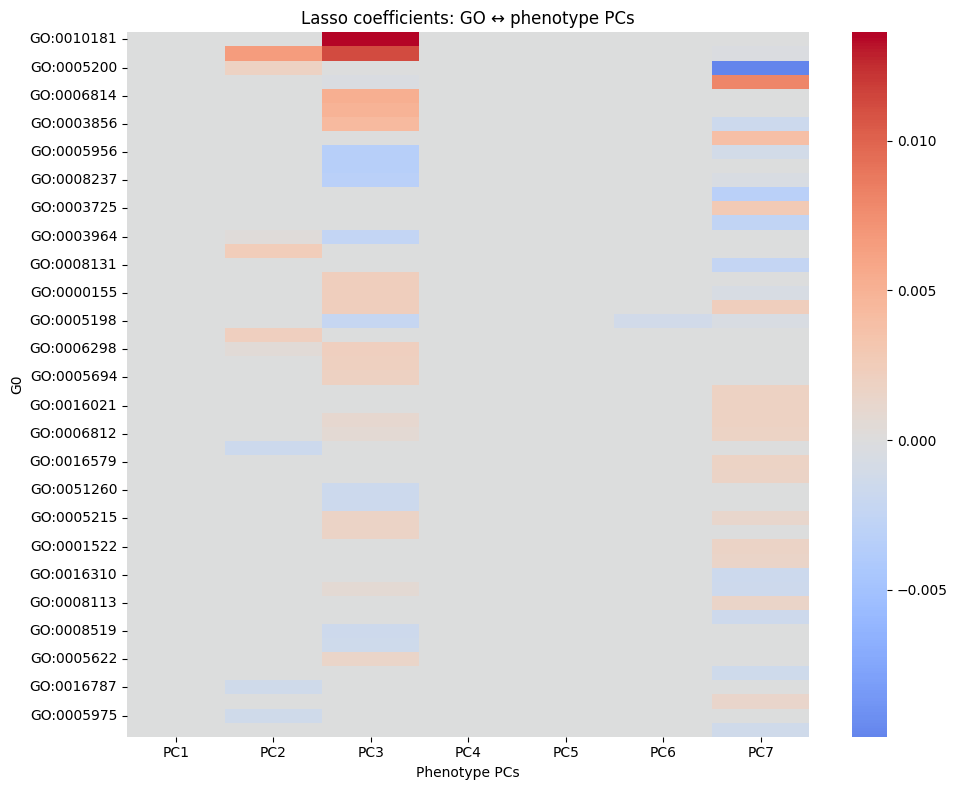

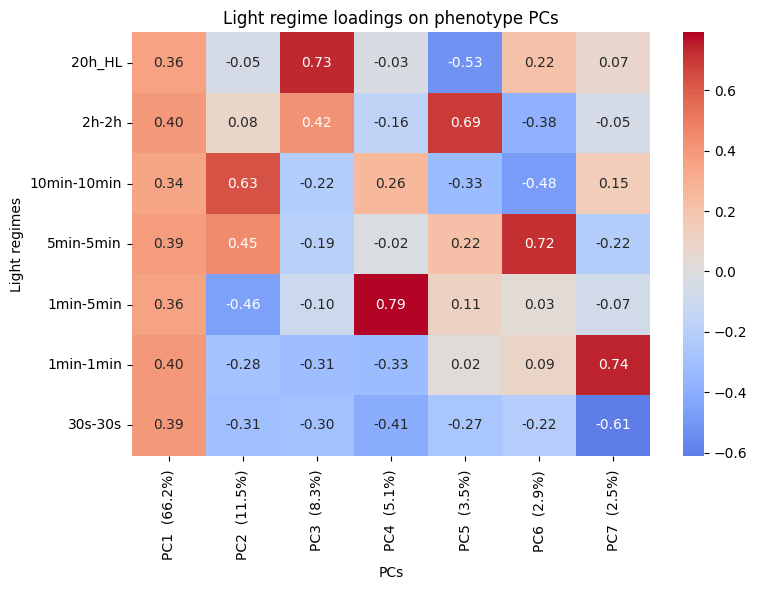

In [34]:
### Creating a binary matrix of aggregated Gos
import pandas as pd
rows = []
for go_term, mutants in aggregated_go_to_mutants.items():
    for m in mutants:
        rows.append((m, go_term))

df_long = pd.DataFrame(rows, columns=['mutated_genes', 'Aggregated_GO'])
print(df_long.head())

# --- Optionally pivot to binary matrix mutant × GO ---
df_binary = pd.crosstab(df_long['mutated_genes'], df_long['Aggregated_GO']).astype(int)
print(df_binary.shape, "matrix")
print(df_binary.shape)
print(df_binary.head())

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
df = data#_out
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]

# --- 0) Construire X (mutant x gènes) et Y (mutant x light_regime) ---
df = df[df['mutant_ID'].notna() & df['mutated_genes'].notna()]
#X = df_binary
Y = df.pivot_table(index='mutated_genes', columns='light_regime',
                   values='y2_slope', aggfunc='mean')
print(X.shape, Y.shape)
Y = Y.replace([np.inf, -np.inf], 0)
Y = Y
common = X.index.intersection(Y.index)
print(len(common), "mutants communs")
X = X.loc[common]
Y = Y.loc[common]
Y = Y.fillna(0)                       # imputation simple
X = X.loc[:, X.var() > 0]                    # drop colonnes constantes
# --- 1) PCA sur Σ_Y (équivalent à PCA sur Y standardisé) ---
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)
K = 7#min(Y_white.shape[1], 2 )               # ex: 6 premières PCs

pca = PCA(n_components=K)                 # garde toutes les composantes
Y_scores = pca.fit_transform(Y_scaled)       # = Y V (en base standardisée)

# (option) whitening pour variance=1 par PC
Y_white = Y_scores / pca.singular_values_
# Choisir combien de PCs on cible avec le Lasso

# --- 2) Lasso: prédire chaque PC de Y via X pour obtenir U parcimonieux ---
# Standardiser X (sans centrer si sparse/binaire)
xscaler = StandardScaler(with_mean=False)
X_scaled = xscaler.fit_transform(X)

alphas = None  # laisse LassoCV choisir
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=alphas)

U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model, model_name = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk), 'Lasso'
    #model, model_name = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5).fit(X_scaled, yk), 'Ridge'
    U_coefs.append(model.coef_)

# Matrice U: gènes x PCs
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])

# --- 3) Résultats utiles ---
# a) Scree plot: pca.explained_variance_ratio_ (si tu veux tracer)
explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# b) Top gènes par PC (par valeur absolue des coeffs)
# def top_go_for_pc(U, pc, n=15):
#     return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])
def top_go_with_desc(U, pc, annotation_file, n=25):
    gi = pd.read_csv(annotation_file, dtype=str)
    meta = (gi[['GO ID','GO Description','Pathway Description', 'Panther Description']]
            .dropna(subset=['GO ID']).drop_duplicates('GO ID').set_index('GO ID'))
    ix = U[pc].abs().nlargest(n).index
    out = pd.DataFrame({'abs_coef': U[pc].abs().loc[ix], 'coef': U[pc].loc[ix]})
    return out.join(meta).sort_values('abs_coef', ascending=False)

# example:
# print(top_go_with_desc(U, 'PC3', annotation_file, n=25))
pc = "PC7"
top_PC = top_go_with_desc(U, pc,'/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv', n=5)
print(pc, pd.DataFrame(top_PC))


# Objets finaux:
# - explained : variance expliquée par PC (pour scree plot)
# - Y_whitened_df : scores blanchis par PC (échantillons x PCs)
# - U : coefficients Lasso (gènes x PCs) = association gènes↔directions phénotypiques
# - top_PC1 (etc.) : gènes majeurs pour chaque PC


# Sort genes by their strongest coefficient magnitude
gene_order = U.abs().max(axis=1).sort_values(ascending=False).index[:50]  # top 50 genes
plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[gene_order], cmap='coolwarm', center=0, annot=False)
plt.title(f"{model_name} coefficients: GO ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("G0")
plt.tight_layout()
plt.show()

pca.fit(Y_scaled)
explained_var = pca.explained_variance_ratio_ * 100
loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,  # original light regimes
                        columns=[f"PC{i+1}  ({explained_var[i]:.1f}%) " for i in range(pca.n_components_)])
order = ["20h_HL", "2h-2h", "10min-10min", 
         "5min-5min", "1min-5min", "1min-1min", "30s-30s"]
loadings = loadings.loc[order]
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt=".2f") #.iloc[:, :2]
plt.title("Light regime loadings on phenotype PCs")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()

Après nettoyage: 342 gènes × 275 GO


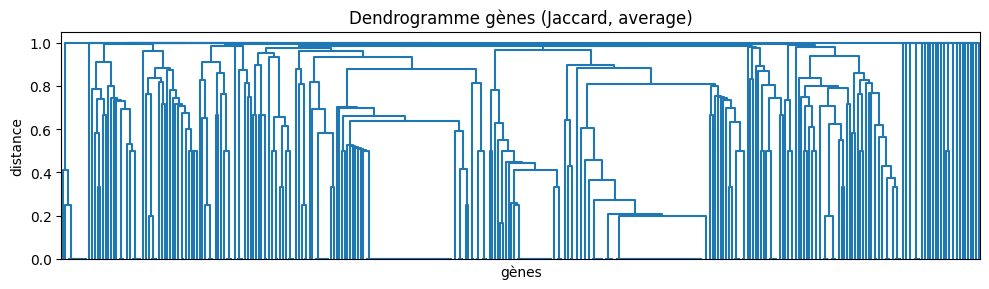

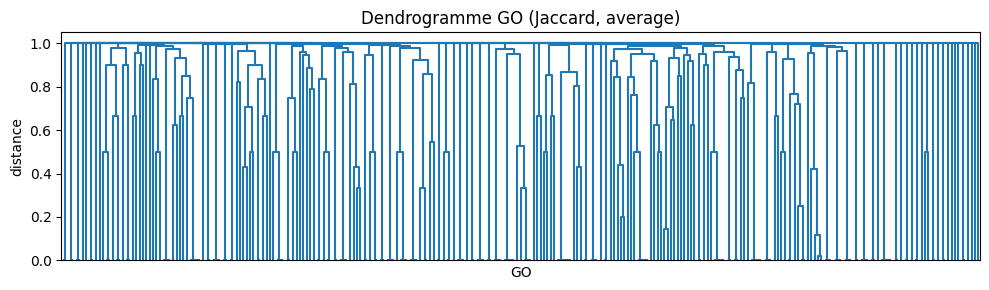


--- Gènes par cluster ---
gene_cluster
0     10
1      6
2     13
3     20
4      1
5      6
6      7
7      6
8      1
9      6
10     9
11     1
12     5
13    10
14    57
15    28
16    68
17     2
18    11
19     1
20     4
21    20
22    19
23     1
24     1
25     2
26     3
27     2
28     2
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     1
47     1
48     1
Name: count, dtype: int64

--- GO par cluster ---
go_cluster
0      2
1      2
2      2
3      2
4      6
      ..
105    1
106    1
107    1
108    1
109    1
Name: count, Length: 110, dtype: int64


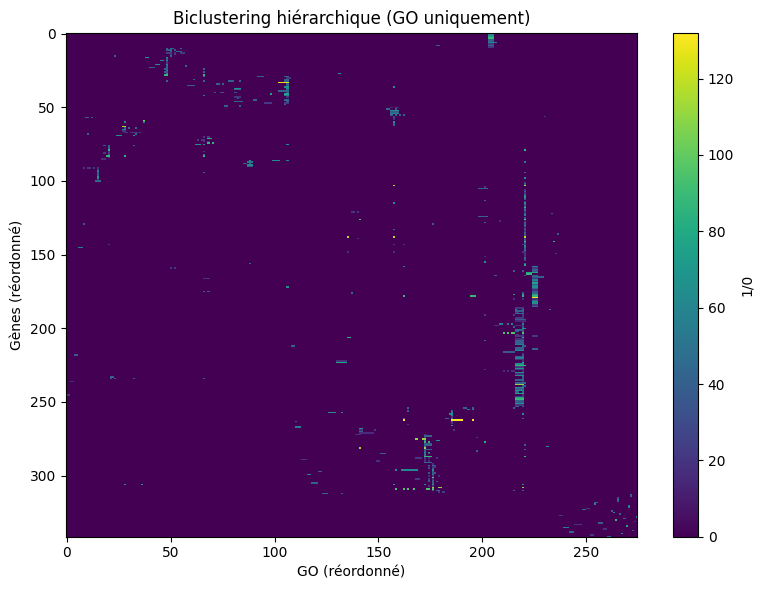

Bicluster (0,0): 10 gènes × 2 GO, densité=0.000
Bicluster (0,1): 10 gènes × 2 GO, densité=0.000
Bicluster (0,2): 10 gènes × 2 GO, densité=0.000
Bicluster (0,3): 10 gènes × 2 GO, densité=0.000
Bicluster (0,4): 10 gènes × 6 GO, densité=0.000
Bicluster (0,5): 10 gènes × 3 GO, densité=0.000
Bicluster (0,6): 10 gènes × 2 GO, densité=0.000
Bicluster (0,7): 10 gènes × 2 GO, densité=0.000
Bicluster (0,8): 10 gènes × 3 GO, densité=0.000
Bicluster (0,9): 10 gènes × 3 GO, densité=0.000
Bicluster (0,10): 10 gènes × 2 GO, densité=0.000
Bicluster (0,11): 10 gènes × 7 GO, densité=0.000
Bicluster (0,12): 10 gènes × 1 GO, densité=0.000
Bicluster (0,13): 10 gènes × 1 GO, densité=0.000
Bicluster (0,14): 10 gènes × 2 GO, densité=0.000
Bicluster (0,15): 10 gènes × 3 GO, densité=0.000
Bicluster (0,16): 10 gènes × 2 GO, densité=0.000
Bicluster (0,17): 10 gènes × 2 GO, densité=0.000
Bicluster (0,18): 10 gènes × 2 GO, densité=0.000
Bicluster (0,19): 10 gènes × 8 GO, densité=0.000
Bicluster (0,20): 10 gènes × 1

In [33]:
#  Jaccard dendogram
#X = df_binary
Xc = X.loc[X.sum(axis=1) > 0, X.sum(axis=0) > 0]
print(f"Après nettoyage: {Xc.shape[0]} gènes × {Xc.shape[1]} GO")

Xb = (Xc.values > 0)
row_dist = pdist(Xb, metric='jaccard')
col_dist = pdist(Xb.T, metric='jaccard')

Z_rows = linkage(row_dist, method='average')
Z_cols = linkage(col_dist, method='average')

plt.figure(figsize=(10, 3))
dendrogram(Z_rows, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme gènes (Jaccard, average)")
plt.xlabel("gènes"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
dendrogram(Z_cols, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme GO (Jaccard, average)")
plt.xlabel("GO"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

ROW_THRESH = 0.9  
COL_THRESH = 0.9

row_labels = fcluster(Z_rows, ROW_THRESH, criterion='distance') - 1
col_labels = fcluster(Z_cols, COL_THRESH, criterion='distance') - 1
gene_labels = pd.Series(row_labels, index=Xc.index, name='gene_cluster')
go_labels   = pd.Series(col_labels, index=Xc.columns, name='go_cluster')

print("\n--- Gènes par cluster ---")
print(gene_labels.value_counts().sort_index())
print("\n--- GO par cluster ---")
print(go_labels.value_counts().sort_index())

rord = np.argsort(row_labels); cord = np.argsort(col_labels)
X_ordered = Xc.iloc[rord, cord]

plt.figure(figsize=(8,6))
plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
plt.title('Biclustering hiérarchique (GO uniquement)')
plt.xlabel('GO (réordonné)'); plt.ylabel('Gènes (réordonné)')
plt.colorbar(label='1/0'); plt.tight_layout(); plt.show()

def get_block(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

def block_density(rows, cols):
    if len(rows)==0 or len(cols)==0: return np.nan
    sub = Xc.loc[rows, cols].values
    return sub.sum() / (sub.shape[0]*sub.shape[1])

for gk in sorted(gene_labels.unique()):
    for fk in sorted(go_labels.unique()):
        r,c = get_block(gk,fk)
        d = block_density(r,c)
        print(f"Bicluster ({gk},{fk}): {len(r)} gènes × {len(c)} GO, densité={d:.3f}")


In [ ]:
import pandas as pd
import numpy as np
def to_set(x):
    if isinstance(x, list): return set(str(v).strip() for v in x if pd.notna(v) and str(v).strip())
    if pd.isna(x): return set()
    return set(str(x).split())  # fallback

df_cmp = df_out.copy()  # your dataframe with columns 'GO' and 'Aggregated_GO'

df_cmp['GO_set']   = df_cmp['GO'].apply(to_set)
df_cmp['Agg_set']  = df_cmp['Aggregated_GO'].apply(to_set)

df_cmp['same']     = df_cmp['GO_set'] == df_cmp['Agg_set']
df_cmp['GO_only']  = df_cmp.apply(lambda r: sorted(r['GO_set'] - r['Agg_set']), axis=1)
df_cmp['Agg_only'] = df_cmp.apply(lambda r: sorted(r['Agg_set'] - r['GO_set']), axis=1)

# Rows where they differ
diff_rows = df_cmp[~df_cmp['same']][['mutated_genes','GO_only','Agg_only']]
print(f"Equal rows: {df_cmp['same'].sum()} / {len(df_cmp)}")
print("First differences:")
print(diff_rows.head(20).to_string(index=False))


In [ ]:
df_out.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv')

In [ ]:
df_out[df_out['mutated_genes']=='Cre13.g589350']